In [117]:
from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.pipeline import Pipeline

In [118]:
data = load_diabetes()

In [119]:
X, y = data.data, data.target

In [120]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

In [121]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
# Applying Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ypred_lr = lr_reg.predict(X_test)

In [124]:
print(f'Coefficient - {lr_reg.coef_}\nIntercept - {lr_reg.intercept_}')

Coefficient - [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Intercept - 151.34560453985995


In [125]:
print('For Linear Regression Model')
print('-'*27)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}%')
print(f'R2-score: {(r2_score(y_test, y_pred)):.2f}%')

For Linear Regression Model
---------------------------
RMSE: 53.85%
R2-score: 0.45%


In [126]:
# Applying Ridge Regression
R = Ridge(alpha=0.01)
R.fit(X_train, y_train)
ypred_R = R.predict(X_test)

In [127]:
print(f'Coefficient - {R.coef_}\nIntercept - {R.intercept_}')

Coefficient - [  40.69342168 -237.00801965  546.16179161  341.80931747 -430.14629956
  129.902301    -60.46081734  203.99084244  541.09802519   55.48255303]
Intercept - 151.3365966317254


In [128]:
print('For Ridge Regression Model')
print('-'*26)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, ypred_R)):.2f}%')
print(f'R2-score: {(r2_score(y_test, ypred_R)):.2f}%')

For Ridge Regression Model
--------------------------
RMSE: 53.69%
R2-score: 0.46%


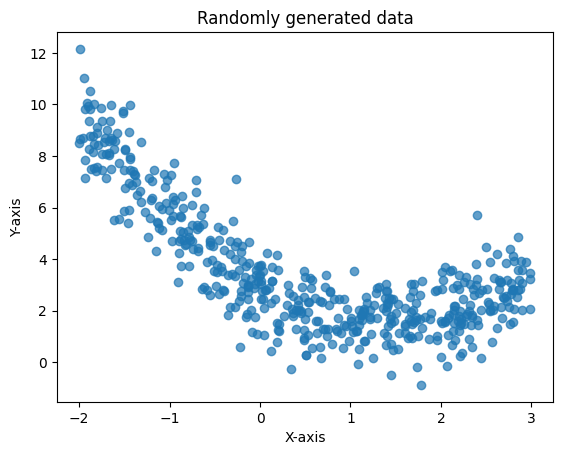

In [129]:
m = 500
x1 = (5*np.random.rand(m, 1) - 2)
x2 = (0.7 * x1**2 - 2*x1 + 3 + np.random.randn(m, 1))
plt.scatter(x1, x2, alpha=0.7)
plt.title('Randomly generated data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

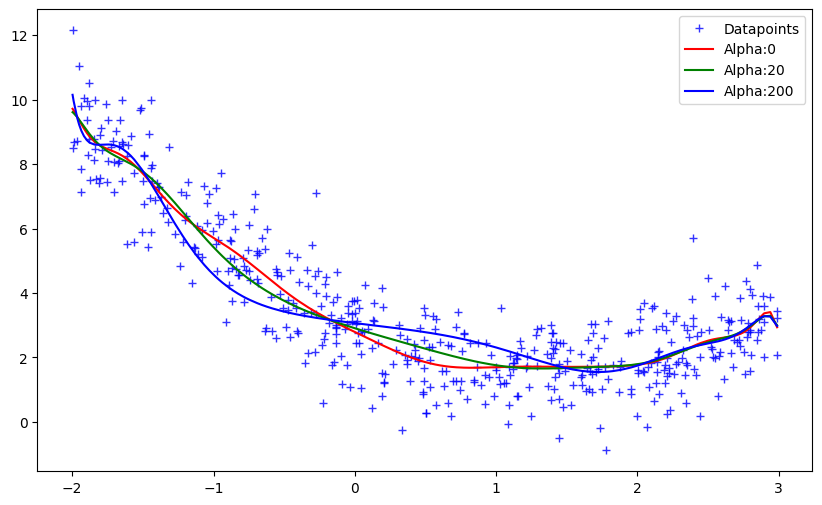

In [130]:
def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)

    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints', alpha=0.8)

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha:{}'.format(alpha))

plt.legend()
plt.show()